In [2]:
!pip install matplotlib numpy pandas seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 11.9 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 11.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.2 MB 11.2 MB/s eta 0:00:01
   -------------------------- ------------- 4.7/7.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 10.8 MB/s  0:00:00

   -----------------------------

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Налаштування стилю для красивих графіків
sns.set_theme(style="whitegrid")

# URL датасету на UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

# Список назв колонок з опису датасету
columns = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price",
]

# Зчитуємо дані
df = pd.read_csv(url, names=columns)

# Показуємо перші 5 рядків
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [6]:
# 1. Замінюємо '?' на NaN (Not a Number)
df.replace("?", np.nan, inplace=True)

# 2. Перетворюємо числові колонки, які через '?' стали текстовими, назад у числа
numeric_cols = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Розумне заповнення пропусків залежно від типу даних
for col in df.columns:
    # Перевіряємо, чи є колонка числовою
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        # Якщо колонка текстова (object або string) — беремо найчастіше значення (моду)
        df[col] = df[col].fillna(df[col].mode()[0])

# Перевіряємо чи не лишилося пропусків (має вивести 0)
print("Кількість пропущених значень після очищення:", df.isnull().sum().sum())

Кількість пропущених значень після очищення: 0


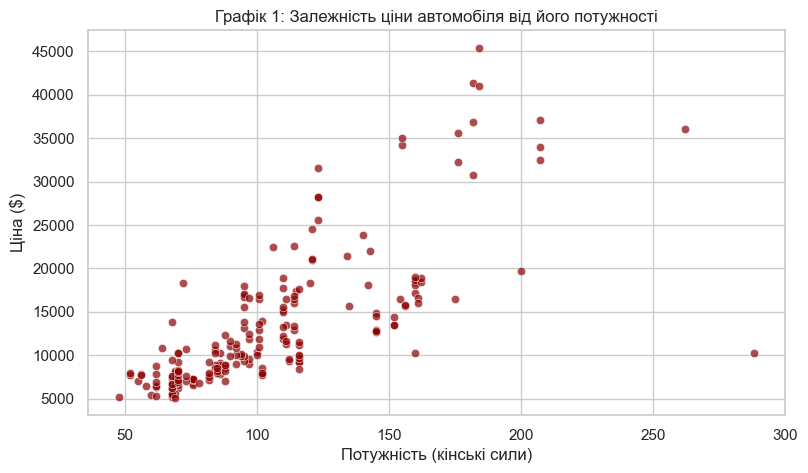

In [7]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="horsepower", y="price", color="darkred", alpha=0.7)

plt.title("Графік 1: Залежність ціни автомобіля від його потужності")
plt.xlabel("Потужність (кінські сили)")
plt.ylabel("Ціна ($)")
plt.show()

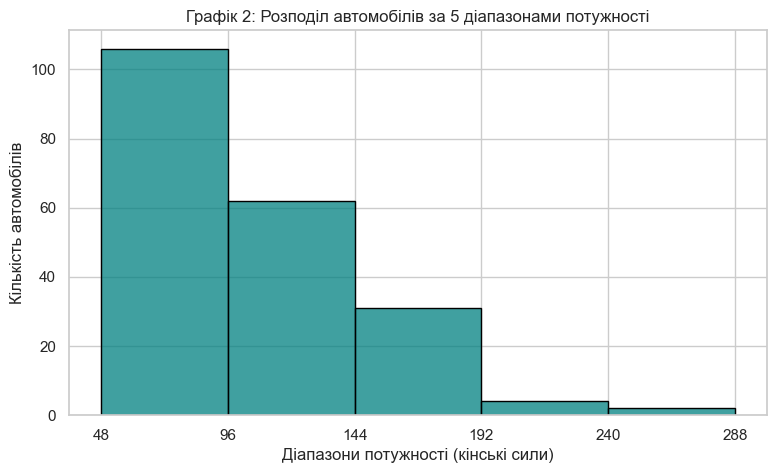

In [8]:
plt.figure(figsize=(9, 5))

# Створюємо рівно 5 діапазонів (для цього потрібно 6 меж)
bins_edges = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 6)

# Будуємо гістограму
sns.histplot(df["horsepower"], bins=bins_edges, color="teal", edgecolor="black")

plt.title("Графік 2: Розподіл автомобілів за 5 діапазонами потужності")
plt.xlabel("Діапазони потужності (кінські сили)")
plt.ylabel("Кількість автомобілів")
plt.xticks(bins_edges)  # Показуємо точні межі діапазонів на осі X
plt.show()

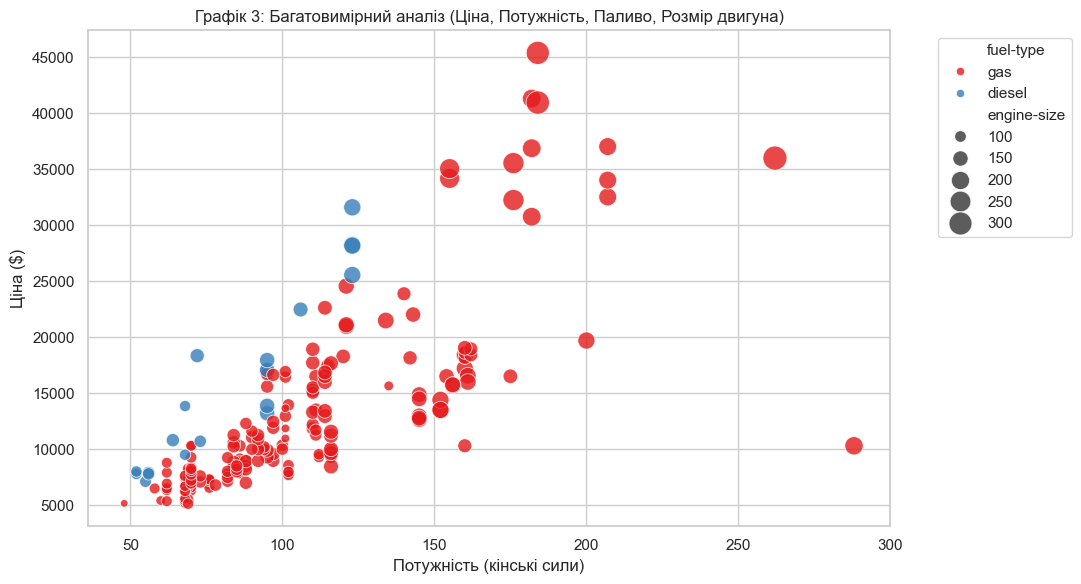

In [9]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="horsepower",
    y="price",
    hue="fuel-type",
    size="engine-size",
    sizes=(30, 300),
    palette="Set1",
    alpha=0.8,
)

plt.title("Графік 3: Багатовимірний аналіз (Ціна, Потужність, Паливо, Розмір двигуна)")
plt.xlabel("Потужність (кінські сили)")
plt.ylabel("Ціна ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

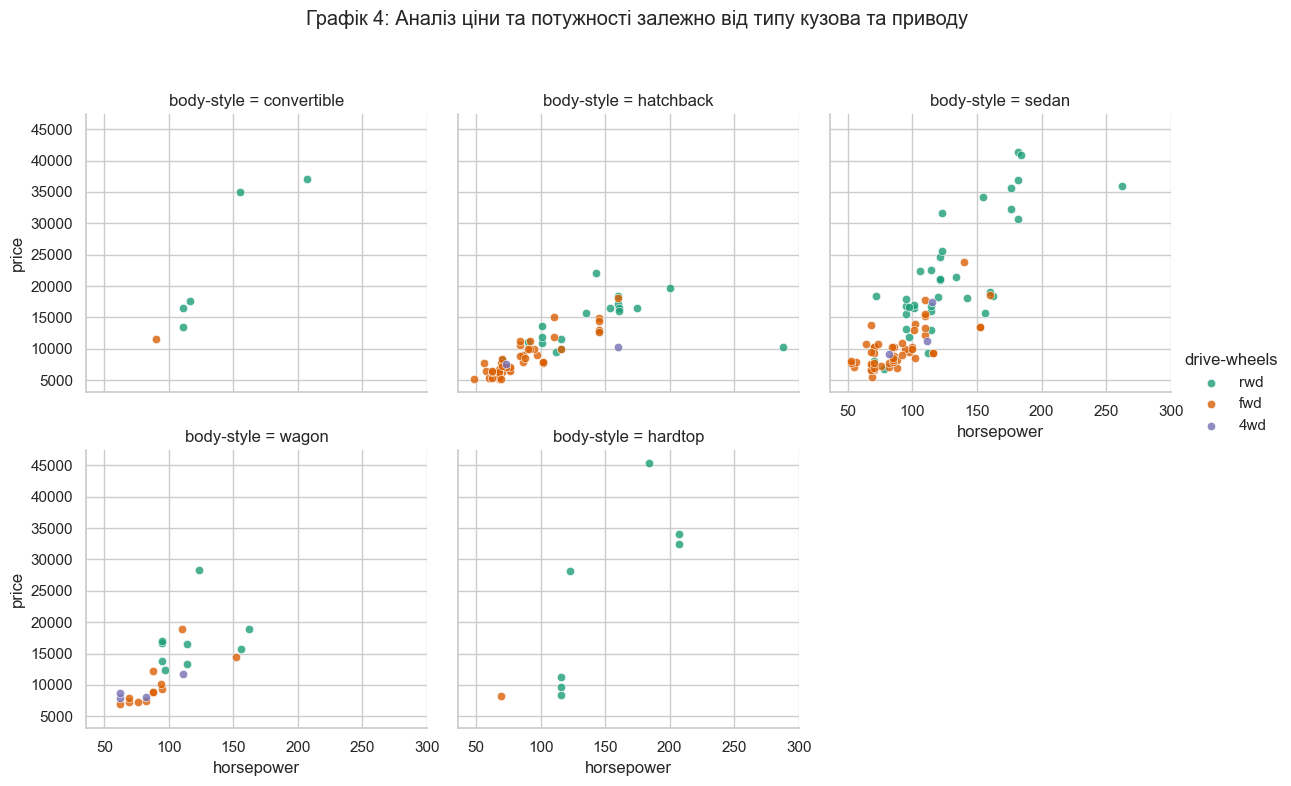

In [10]:
g = sns.FacetGrid(df, col="body-style", hue="drive-wheels", palette="Dark2", col_wrap=3, height=4)
g.map(sns.scatterplot, "horsepower", "price", alpha=0.8)

g.add_legend()
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Графік 4: Аналіз ціни та потужності залежно від типу кузова та приводу")
plt.show()


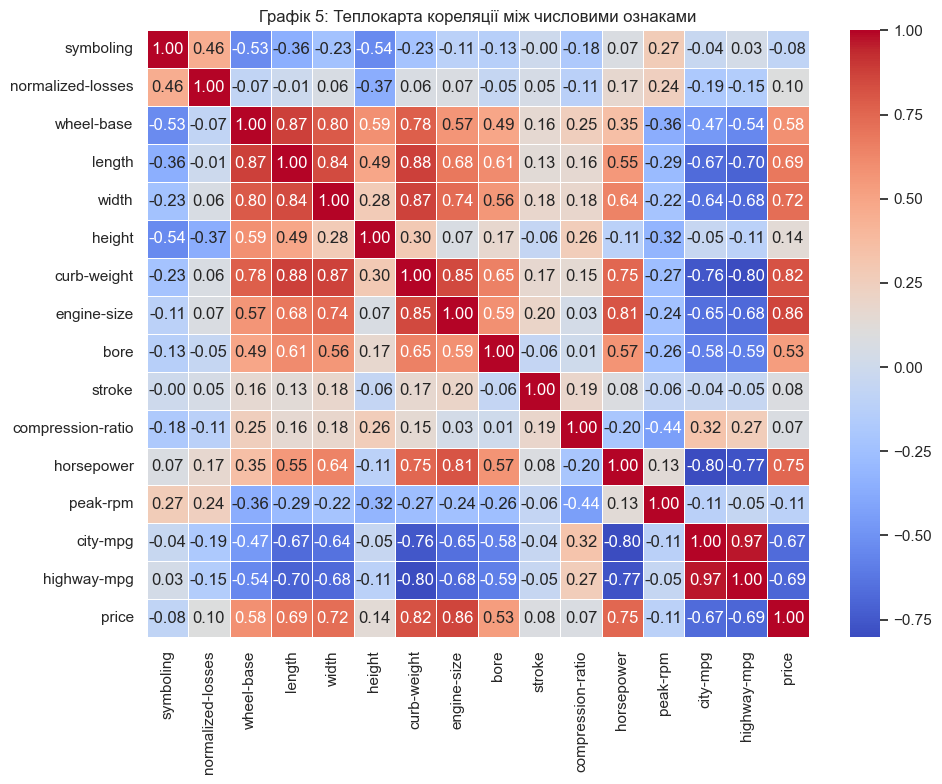

In [11]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Графік 5: Теплокарта кореляції між числовими ознаками")
plt.tight_layout()
plt.show()

C:\Users\7777\AppData\Local\Temp\ipykernel_60716\3107386482.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_makes, x="make", y="price", palette="Pastel1")


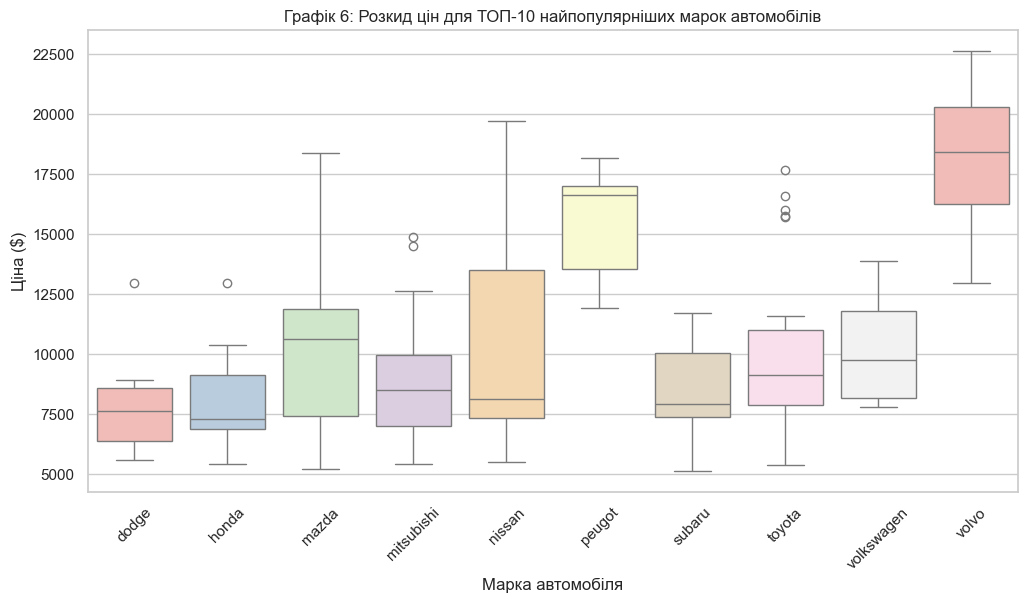

In [12]:
plt.figure(figsize=(12, 6))

# Беремо топ-10 найпопулярніших брендів
top_makes = df["make"].value_counts().nlargest(10).index
df_top_makes = df[df["make"].isin(top_makes)]

sns.boxplot(data=df_top_makes, x="make", y="price", palette="Pastel1")

plt.title("Графік 6: Розкид цін для ТОП-10 найпопулярніших марок автомобілів")
plt.xlabel("Марка автомобіля")
plt.ylabel("Ціна ($)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
 Серед популярних марок найдорожчою є BMW, яка має також найбільший розкид цін. Найбільш бюджетними та стабільними в ціні є Toyota, Nissan, Honda та Subaru.